## Load in data

In [1]:
import pandas as pd

In [2]:
dataset = pd.read_parquet('../data/processed/features.parquet')
dataset.head()

,user_id,item_id,rating,timestamp,movie_title,release_date,video_release_date,imdb_url,genre_0,genre_1,...,genre_14,genre_15,genre_16,genre_17,genre_18,age,gender,occupation,zip_code,click
0,196,242,3,881250949,Kolya (1996),24-Jan-1997,NaN,http://us.imdb.com/M/title-exact?Kolya%20(1996),0,0,...,0,0,0,0,0,49,M,writer,55105,0
1,186,302,3,891717742,L.A. Confidential (1997),01-Jan-1997,NaN,http://us.imdb.com/M/title-exact?L%2EA%2E+Conf...,0,0,...,0,0,1,0,0,39,F,executive,00000,0
2,22,377,1,878887116,Heavyweights (1994),01-Jan-1994,NaN,http://us.imdb.com/M/title-exact?Heavyweights%...,0,0,...,0,0,0,0,0,25,M,writer,40206,0
3,244,51,2,880606923,Legends of the Fall (1994),01-Jan-1994,NaN,http://us.imdb.com/M/title-exact?Legends%20of%...,0,0,...,1,0,0,1,1,28,M,technician,80525,0
4,166,346,1,886397596,Jackie Brown (1997),01-Jan-1997,NaN,http://us.imdb.com/M/title-exact?imdb-title-11...,0,0,...,0,0,0,0,0,47,M,educator,55113,0


## Train The Models

### Variant A : Collaborative Filtering


For our first model, we are going to do collaborative filtering. In collaborative filtering, we recommend items to users that other similar users have also liked.

For our first baseline model we will be using KNNwithMeans which builds upon normal KNNBasic. In KNNBasic, we use the K nearest neighbours' ratings at face values, whereas 'withMeans' adjusts for user bias in terms of how they rate by centering ratings around user averages. Additionally, we are using cosine similarity as our distance metric

In [5]:
from surprise import Dataset, Reader, KNNWithMeans

# create the reader for rating
reader = Reader(rating_scale=(1, 5))

# load the dataset from the data from the previous notebook
data = Dataset.load_from_df(dataset[['user_id', 'item_id', 'rating']], reader)

# we are going to do item-based 
sim_options = {"name" : "cosine", "user_based": False}
# use KNNWithMeans algorithm for collaborative filtering
algo = KNNWithMeans(sim_options=sim_options)

In [6]:
from surprise.model_selection import train_test_split
from surprise import accuracy

trainset, testset = train_test_split(data, test_size= 0.2)

# train the algorithm on the train set
algo.fit(trainset)

# get the predictions of the test set
predictions = algo.test(testset)

Computing the cosine similarity matrix...
Done computing similarity matrix.


Now that we have the predictions we should calculate the root mean square error and mean absolute error. We are also converting the predicted ratings into a probability of that movie being clicked by the user; from this we can get the simulated CTR for variant A. We also calculate AUC which is the area under the curve indicating how well our model distinguished between classes (click / no click), getting a score of 0.774 (where 1 perfect).

In [7]:
print(f"RMSE: {accuracy.rmse(predictions)}")
print(f"MAE: {accuracy.mae(predictions)}")

RMSE: 0.9461
RMSE: 0.9460929205851318
MAE:  0.7442
MAE: 0.7442044520551429


In [8]:
# get the predicted ratings 
pred_ratings = [pred.est for pred in predictions]

# get the true ratings
true_ratings = [pred.r_ui for pred in predictions]

# comvert the probably of a person clicking on a movie according to the predicted rating
pred_click_prob = [(r - 1) / 4 for r in pred_ratings]

In [9]:
from sklearn.metrics import roc_auc_score

# calculate the average CTR for our first model by taking average of all probabilities
variant_a_ctr = sum(pred_click_prob) / len(pred_click_prob)
print(f"Variant A simulated CTR: {variant_a_ctr:.4f}")

# get the true clicks based on 5 star threshold
true_clicks = [1 if r >= 5 else 0 for r in true_ratings] 
# get the auc
auc = roc_auc_score(true_clicks, pred_click_prob)
print(f"Variant A AUC: {auc:.4f}")


Variant A simulated CTR: 0.6350
Variant A AUC: 0.7710


### Variant B : LightGBM Ranker

Our previous model only used data on the users, their ratings and what they rated. By relating similar users and their ratings, we can provide outputs with collaborative filtering. In variant B, though we will be using the features of the products ie. the movies to predict the probability of a click.

First, we will define the features that we are going to use for the users and for the movie items.

In [10]:
# add additional stats of user click rate and ratings and item click rates and item ratings
user_stats = dataset.groupby('user_id')['click'].agg(['mean', 'count']).rename(
    columns={'mean': 'user_click_rate', 'count': 'user_num_ratings'})
item_stats = dataset.groupby('item_id')['click'].agg(['mean', 'count']).rename(
    columns={'mean': 'item_click_rate', 'count': 'item_num_ratings'})

df = dataset.merge(user_stats, on='user_id').merge(item_stats, on='item_id')

In [11]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
# split into train and test

train_data, test_data = train_test_split(dataset, test_size=0.2, random_state=42, stratify=dataset['click'])

In [12]:
# add additional stats of user clicks and ratings for the train only 
user_stats = train_data.groupby('user_id')['click'].agg(['mean', 'count']).rename(
    columns={'mean': 'user_click_rate', 'count': 'user_num_ratings'})
item_stats = train_data.groupby('item_id')['click'].agg(['mean', 'count']).rename(
    columns={'mean': 'item_click_rate', 'count': 'item_num_ratings'})

# deafult value for null values so we will add the mean
all_clicks = train_data['click'].mean()

train_data = train_data.merge(user_stats, on='user_id', how='left').merge(item_stats, on='item_id', how='left')
test_data = test_data.merge(user_stats, on='user_id', how='left').merge(item_stats, on='item_id', how='left')


In [13]:
# use the mean to fill in null values in terms of clicks
for col in ['user_click_rate', 'item_click_rate']:
    train_data[col] = train_data[col].fillna(all_clicks)
    test_data[col] = test_data[col].fillna(all_clicks)

# fill ratings as default 0
for col in ['user_num_ratings', 'item_num_ratings']:
    train_data[col] = train_data[col].fillna(0)
    test_data[col] = test_data[col].fillna(0)

In [14]:
# encode the string labels of some features
le_gender = LabelEncoder()
le_occupation = LabelEncoder()

train_data['gender_enc'] = le_gender.fit_transform(train_data['gender'])
test_data['gender_enc'] = le_gender.transform(test_data['gender'])

# only transform this not fit so they align with how it was transformed in the train
train_data['occupation_enc'] = le_occupation.fit_transform(train_data['occupation'])
test_data['occupation_enc'] = le_occupation.transform(test_data['occupation'])

In [15]:
# define our feature columns
genre_cols = [f'genre_{i}' for i in range(19)]
feature_cols_b = ['age', 'gender_enc', 'occupation_enc', 'user_click_rate', 'item_click_rate', 'item_num_ratings', 'user_num_ratings'] + genre_cols

X_train = train_data[feature_cols_b]
X_test = test_data[feature_cols_b]
y_train = train_data['click']
y_test = test_data['click']

In [16]:
import lightgbm as lgbm

# create our train and test data for lightgbm
light_train = lgbm.Dataset(X_train, label=y_train)
light_test = lgbm.Dataset(X_test, label=y_test)

# set out params
params = {
    'objective' : 'binary',
    'metric' : 'auc',
    'verbosity' : -1,
    'boosting_type' : 'gbdt'
}

# train the model
model = lgbm.train(
    params=params,
    train_set=light_train,
    num_boost_round=100,
    valid_sets=[light_test],
    callbacks=[lgbm.early_stopping(stopping_rounds=10)]
)

Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[99]	valid_0's auc: 0.792143


In [17]:
from sklearn.metrics import roc_auc_score

pred_click_probs_b = model.predict(X_test, num_iteration=model.best_iteration)

auc_b = roc_auc_score(y_test, pred_click_probs_b)
print(f"Variant B AUC: {auc_b:.4f}")
variant_b_ctr = sum(pred_click_probs_b) / len(pred_click_probs_b)
print(f'Variant B CTR {variant_b_ctr:.4f}')

Variant B AUC: 0.7921
Variant B CTR 0.2120


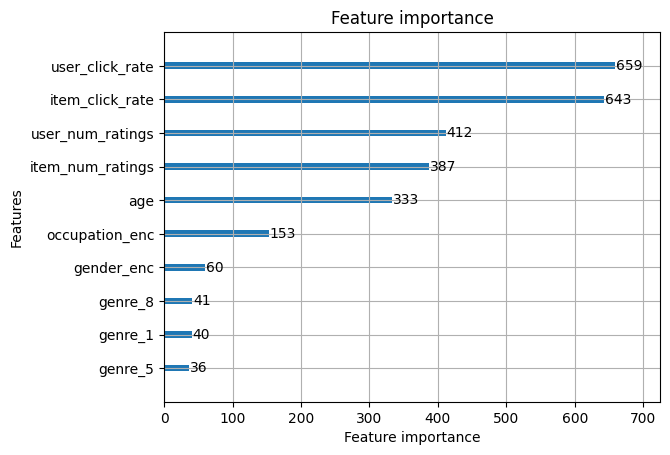

In [18]:
import matplotlib.pyplot as plt

# plot the importance of each feature
lgbm.plot_importance(model, max_num_features=10)
plt.show()

Now, that we have trained our variant B model, we can see that the AUC score is slighly higher than variant A, which suggests that its ability to separate the click vs. no click classes is higher. As for the simulated CTR, though it was significantly lower than variant A, which could be attributed to the fact of how we are assigning a click vs. no click, though this lower CTR rate maybe actually be more accurate to real life representations.

### Variant C : LightFM 

In variant A, we used collaborative filtering and in variant B we trained a model based on the content / features of the users and movies. In this final variant, we will combine collaborative filtering and content-based filtering using LightFM.    


In [21]:
from lightfm.data import Dataset as LFMDataset

lfm_dataset = LFMDataset()

# make mapping of user id and item ids
lfm_dataset.fit(
    users=dataset['user_id'].unique(),
    items=dataset['item_id'].unique()
)

In [22]:
# build interaction matrices for the collaborative filtering part on the item, user and click

(train_interactions, train_weights) = lfm_dataset.build_interactions([(row.user_id, row.item_id, row.click) for row in train_data.itertuples()])

In [23]:
genre_cols = [f"genre_{i}" for i in range(19)]

item_features_list = dataset[['item_id'] + genre_cols].drop_duplicates('item_id')

item_features_tupes = [
    (row.item_id, [g for g in genre_cols if getattr(row, g) == 1])
    for row in item_features_list.itertuples()
]

In [24]:
# for the features 
lfm_dataset.fit_partial(
    items=dataset['item_id'].unique(),
    item_features=genre_cols
)

In [26]:
item_features = lfm_dataset.build_item_features(item_features_tupes)

For the training, we will use logisitic to treat the model classificiation as a binary classification of click or no click. This process with use the interactions between the users and the items through the train_interactions but also take into account the features of the items (ie the genre of the movies) through the item_features.

In [31]:
from lightfm import LightFM
# train the model
model = LightFM(loss='logistic', no_components=30, random_state=42)

model.fit(
    train_interactions,
    item_features=item_features,
    epochs=20,
    num_threads=4
)

In [34]:
(test_interactions, test_weights) = lfm_dataset.build_interactions(
    [(row.user_id, row.item_id, row.click) for row in test_data.itertuples()]
)

In [35]:
from lightfm.evaluation import auc_score

auc_c = auc_score(
    model, 
    test_interactions,
    item_features=item_features,
    num_threads=4
).mean()

In [37]:
# get predicted probs for simulated CTR
import numpy as np
u_id_map, _, i_id_map, _ =lfm_dataset.mapping()

test_user_ids = test_data['user_id'].map(u_id_map).values
test_item_ids = test_data['item_id'].map(i_id_map).values

scores = model.predict(test_user_ids, test_item_ids, item_features=item_features)


# apply sigmoid to scores
pred_click_prob_c = 1 / (1 + np.exp(-scores))

variant_c_ctr = pred_click_prob_c.mean()

print(f"Variant C AUC: {auc_c:.4f}")
print(f'Variant C CTR {variant_c_ctr:.4f}')

Variant C AUC: 0.6256
Variant C CTR 0.9983


### Get the final precision@k values

Precision@k is a metric for recommendation systems, that shows out of the top k item, how many were actually relevant to the user (ie. would they have clicked it). Here, we will check the relevant of the top 10 items.

In [44]:

def precision_at_k(test_df, pred_col, k=10):

    precisions = []

    # for every user
    for user_id, group in test_df.groupby('user_id'):
        # get the top k values
        top_k = group.sort_values(pred_col, ascending=False).head(k)

        if len(top_k) == 0:
            continue

        precision = top_k['click'].sum() / len(top_k)
        precisions.append(precision)

    return np.mean(precisions)

In [46]:
test_df = test_data

test_df['pred_prob_a'] = pred_click_prob
test_df['pred_prob_b'] = pred_click_probs_b
test_df['pred_prob_c'] = pred_click_prob_c

p_a_10 = precision_at_k(test_df, 'pred_prob_a')
p_b_10 = precision_at_k(test_df, 'pred_prob_b')
p_c_10 = precision_at_k(test_df, 'pred_prob_c')

print(f"Variant A Precision@10: {p_a_10:.4f}")
print(f"Variant B Precision@10: {p_b_10:.4f}")
print(f"Variant C Precision@10: {p_c_10:.4f}")


Variant A Precision@10: 0.2267
Variant B Precision@10: 0.2999
Variant C Precision@10: 0.2328
